# Testing the Performance of HypEx Functions

## Imports

In [34]:
import time
import tracemalloc
from collections import defaultdict
from typing import Dict, Union, Any, Optional, TypedDict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hypex import (
    AATest,
    ABTest,
    Matching,
    HomogeneityTest,
)

from hypex.dataset import (
    Dataset,
    InfoRole,
    ExperimentData,
    TreatmentRole,
    TargetRole,
    StratificationRole,
)

## PerformanceTester
### Performance Testing: Measuring Time and Memory & Synthetic Data Generator

In [35]:
class DataProfiler():

    default_params = {
        'n_columns': 50,
        'n_rows': 1000,
        'n2c_ratio': 0.7,
        'rs': 42,
        'num_range': (-100, 100),
        'n_categories': 10
    }

    def __init__(
        self,
        n_columns: Union[int, List[int]] = None,
        n_rows: Union[int, List[int]] = None,
        n2c_ratio: Union[float, List[float]] = None,
        rs: Optional[int] = None,
        num_range: Union[Tuple[float, float], List[Tuple[float, float]]] = None,
        n_categories: Union[int, List[int]] = None
    ):
        """
        Parameters:
        - n_columns: Number of columns (integer or list of integers).
        - n_rows: Number of rows (integer or list of integers).
        - n2c_ratio: Ratio of numeric to categorical columns (float or list of floats).
        - rs: Random seed for reproducibility (optional integer).
        - num_range: Range for numeric values as a tuple or list of tuples.
        - n_categories: Number of categories for categorical variables (integer or list of integers).
        """

        def _format(param):
            return param if isinstance(param, list) else [param]

        self.params = {
        'n_columns': _format(n_columns),
        'n_rows': _format(n_rows),
        'n2c_ratio': _format(n2c_ratio),
        'rs': _format(rs),
        'num_range': _format(num_range),
        'n_categories': _format(n_categories),
        }

    @staticmethod
    def _generate_synthetic_data(
        n_columns: int = default_params['n_columns'],
        n_rows: int = default_params['n_rows'],
        n2c_ratio: float = default_params['n2c_ratio'],
        rs: int = default_params['rs'],
        num_range: tuple = default_params['num_range'],
        n_categories: int = default_params['n_categories']
    ) -> pd.DataFrame:
        """Creates data for tests.

        Args:
            n_columns: number of columns
            n_rows: number of rows
            n2c_ratio: ratio of numerical to categorical columns
            rs: random state for np
            num_range: range for integer values (inclusive, exclusive)

        Returns:
            data: DataFrame with the generated test data
        """

        if rs is not None:
            np.random.seed(rs)

        n_numerical = int(n_columns * n2c_ratio)
        n_categorical = n_columns - n_numerical

        numerical_data = np.random.randint(
            num_range[0], num_range[1], size=(n_rows, n_numerical)
        )

        categories = [f"Category_{i+1}" for i in range(n_categories)]
        categorical_data = np.random.choice(categories, size=(n_rows, n_categorical))

        data = pd.DataFrame(
            np.hstack((numerical_data, categorical_data)),
            columns=[f"num_col_{i}" for i in range(n_numerical)]
            + [f"cat_col_{i}" for i in range(n_categorical)],
        )

        return data
    
    def _create_dataset(self, param: List) -> Dataset:
        data = self._generate_synthetic_data(**param)
        return Dataset(
            roles={
                data.columns[0]: TreatmentRole(int),
                data.columns[1]: TargetRole(int),
            },
            data=data
        )
    
    def get_data(self):
        for param_name, params in self.params.items():
            for param in params:
                if param is not None:
                    yield param_name, param, self._create_dataset({param_name: param})

In [36]:
class ExperimentProfiler:
    def __init__(
        self,
        experiment: Union[AATest, ABTest, Matching, HomogeneityTest],
        experiment_params: Dict = None
    ):
        self.experiment = experiment
        self.experiment_params = experiment_params
    
    def get_experiment(self):
        return self.experiment(**self.experiment_params)

In [37]:
class Output:

    def __init__(self, data: Dict):
        self.data = data

    def show(self):
        for param_name, param_data in self.data.items():
            self._plot_performance(param_name, param_data)

    def _plot_performance(self, param_name: str, param_data: Dict):
        param_values = list(param_data.keys())
        exec_times = [entry[1] if entry[1] is not None else 0 for entry in param_data.values()]
        memory_usages = [entry[2] if entry[2] is not None else 0 for entry in param_data.values()]

        _, ax = plt.subplots(1, 2, figsize=(12, 6))

        ax[0].plot(param_values, exec_times, marker='o', color='b', label='Execution Time')
        ax[0].set_title(f"Execution Time vs {param_name}")
        ax[0].set_xlabel(param_name)
        ax[0].set_ylabel("Execution Time (seconds)")
        ax[0].legend()

        ax[1].plot(param_values, memory_usages, marker='o', color='r', label='Memory Usage')
        ax[1].set_title(f"Memory Usage vs {param_name}")
        ax[1].set_xlabel(param_name)
        ax[1].set_ylabel("Memory Usage (MB)")
        ax[1].legend()

        plt.tight_layout()
        plt.show()

In [38]:
class PerformanceTester:

    def __init__(
        self,
        dataProfiler: DataProfiler,
        experimentProfiler: ExperimentProfiler,
        use_time: bool = True,
        use_memory: bool = True
    ):
        self.dataProfiler = dataProfiler
        self.experimentProfiler = experimentProfiler
        self.use_time = use_time
        self.use_memory = use_memory

    def execute(self) -> Output:
        resume = defaultdict(dict)
        experiment = self.experimentProfiler.get_experiment()
        for param_name, param, data in self.dataProfiler.get_data():
            print(f'{param_name}: {param}') #log
            resume[param_name][param] = self.test_function_performance(
                experiment.execute,
                param_dict={'data': data}
            )
        return Output(resume)
            
    def test_function_performance(self, func, param_dict):
        """
        Tests the performance of the specified function.

        :param func: The function to test
        :param args: Positional arguments for the function
        :param use_time: If True, measures execution time
        :param use_memory: If True, measures memory usage
        :param kwargs: Keyword arguments for the function
        :return: The result of the function execution
        """
        param_dict = param_dict or {}
        exec_time = None
        memory_usage = None

        if self.use_time:
            start_time = time.time()

        if self.use_memory:
            tracemalloc.start()

        result = func(**param_dict)

        if self.use_memory:
            _, memory_usage = tracemalloc.get_traced_memory()
            tracemalloc.stop()

        if self.use_time:
            end_time = time.time()
            exec_time = end_time - start_time

        if self.use_time:
            print(f"Execution time of '{func.__name__}': {exec_time:.4f} seconds") #log

        if self.use_memory:
            print(f"Memory usage of '{func.__name__}': {(memory_usage / 10**6):.4f} MB") #log

        return(
            result,
            exec_time if self.use_time else None,
            memory_usage if self.use_memory else None
        )

In [ ]:
tester = PerformanceTester(
    experimentProfiler=ExperimentProfiler(
        experiment=AATest,
        experiment_params={
            'n_iterations': 10
        }
    ),
    dataProfiler=DataProfiler(
        n_columns = [10, 50, 100, 500, 1000, 5000, 10000],
    ),
    use_time=True,
    use_memory=True
)
output = tester.execute()

n_columns: 10
Execution time of 'execute': 10.8498 seconds
Memory usage of 'execute': 4.5198 MB
n_columns: 50


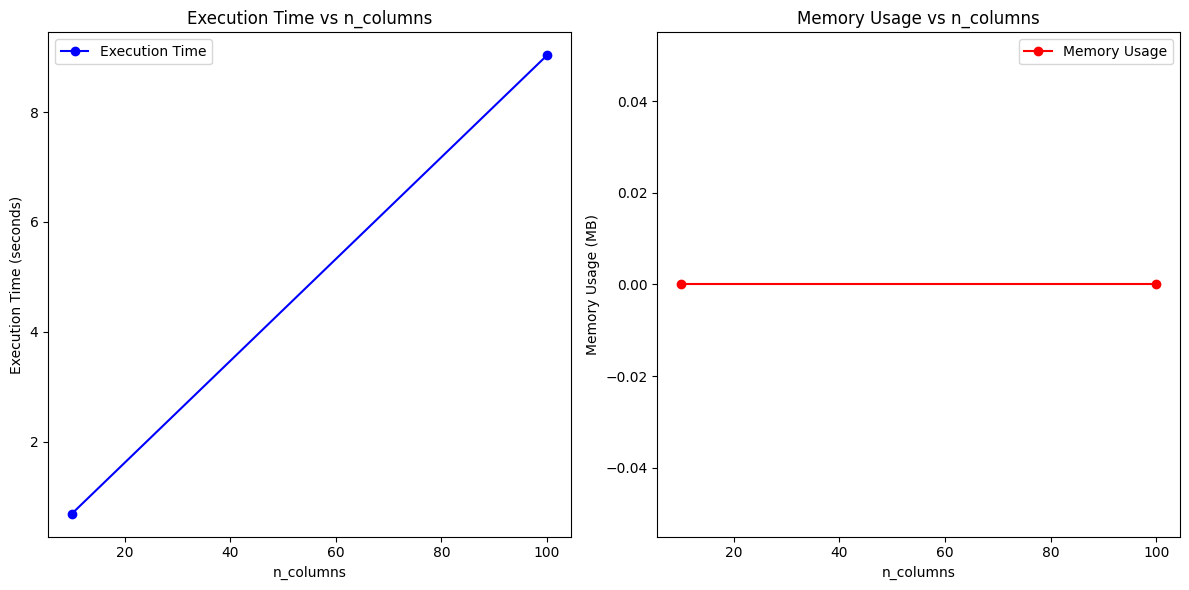

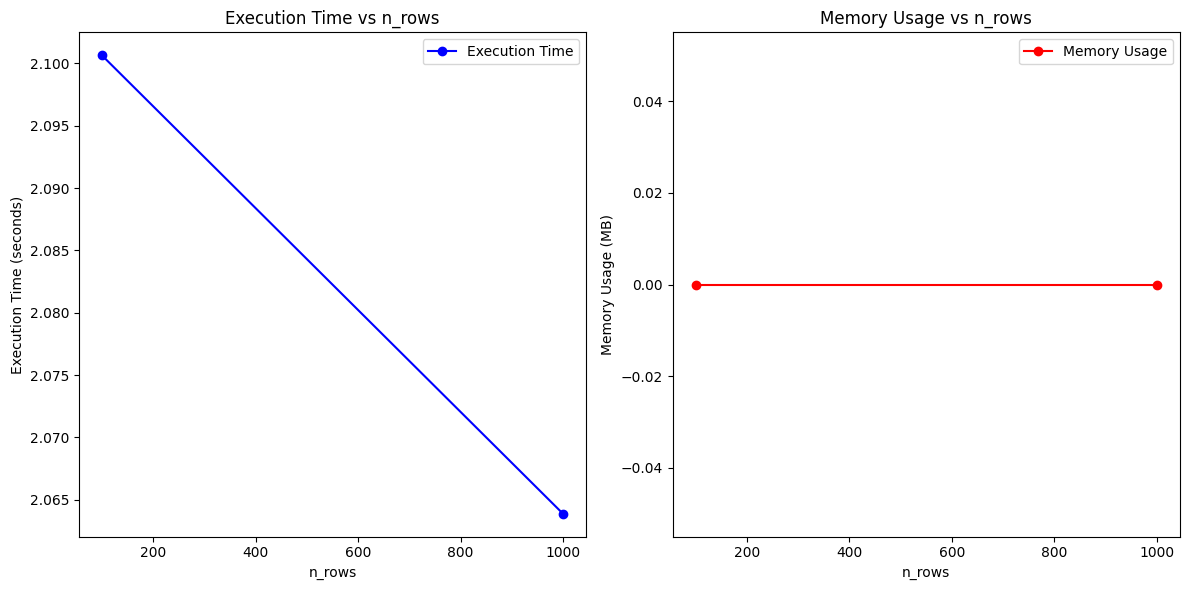

In [21]:
data = output.show()